In [1]:
!ls ../input/fire-seg-2/processed_data

data.yaml  images  labels


In [2]:
%%capture
!pip install torch torchvision segmentation-models-pytorch transformers albumentations opencv-python

In [3]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class YOLOSegDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=512, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def load_mask(self, label_path, h, w):
        mask = np.zeros((h, w), dtype=np.uint8)

        if not os.path.exists(label_path):
            return mask

        with open(label_path, "r") as f:
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                cls = int(parts[0])
                coords = np.array(parts[1:]).reshape(-1, 2)

                coords[:, 0] *= w
                coords[:, 1] *= h
                coords = coords.astype(np.int32)

                cv2.fillPoly(mask, [coords], 1)

        return mask

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(
            self.label_dir, img_name.replace(".jpg", ".txt").replace(".png", ".txt")
        )

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        mask = self.load_mask(label_path, h, w)

        img = cv2.resize(img, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [4]:
import albumentations as A

train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

val_tfms = None

In [5]:
import segmentation_models_pytorch as smp

unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [6]:
deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [7]:
from transformers import SegformerForSemanticSegmentation

segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=1,
    ignore_mismatched_sizes=True
)

2025-12-18 05:07:15.756798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766034435.934864      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766034435.985654      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766034436.417510      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766034436.417550      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766034436.417553      24 computation_placer.cc:177] computation placer alr

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([1, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

def train_model(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.BCEWithLogitsLoss()

    total_loss = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()

        if "segformer" in model.__class__.__name__.lower():
            out = model(pixel_values=imgs).logits
            out = nn.functional.interpolate(out, size=masks.shape[-2:], mode="bilinear")
        else:
            out = model(imgs)

        loss = loss_fn(out, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [9]:
def segmentation_metrics(logits, masks, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * masks).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + masks.sum(dim=(2,3)) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=(2,3)) + masks.sum(dim=(2,3)) + eps)

    return iou.mean().item(), dice.mean().item()


In [10]:
@torch.no_grad()
def validate_model(model, loader, device):
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss()

    total_loss, total_iou, total_dice = 0, 0, 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        if "segformer" in model.__class__.__name__.lower():
            logits = model(pixel_values=imgs).logits
            logits = nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear"
            )
        else:
            logits = model(imgs)

        loss = loss_fn(logits, masks)
        iou, dice = segmentation_metrics(logits, masks)

        total_loss += loss.item()
        total_iou += iou
        total_dice += dice

    n = len(loader)
    return total_loss / n, total_iou / n, total_dice / n


In [11]:
import os
import torch
from transformers import PreTrainedModel

class BestModelSaver:
    def __init__(self, save_dir, monitor="dice", mode="max"):
        """
        save_dir:
            - folder for HuggingFace models
            - .pth file path for torch models
        """
        self.monitor = monitor
        self.mode = mode
        self.best_score = -float("inf") if mode == "max" else float("inf")
        self.save_dir = save_dir

        os.makedirs(save_dir, exist_ok=True)

    def _is_better(self, score):
        return score > self.best_score if self.mode == "max" else score < self.best_score

    def _save_torch(self, model, score, epoch):
        torch.save({
            "epoch": epoch,
            "best_score": score,
            "model_state": model.state_dict()
        }, os.path.join(self.save_dir, "best.pth"))

    def _save_hf(self, model, score, epoch):
        model.save_pretrained(self.save_dir)
        torch.save({
            "epoch": epoch,
            "best_score": score
        }, os.path.join(self.save_dir, "meta.pt"))

    def update(self, score, model, epoch):
        if not self._is_better(score):
            return False

        self.best_score = score

        if isinstance(model, PreTrainedModel):
            self._save_hf(model, score, epoch)
            print(f"💾 Saved BEST HF model ({self.monitor}={score:.4f})")
        else:
            self._save_torch(model, score, epoch)
            print(f"💾 Saved BEST Torch model ({self.monitor}={score:.4f})")

        return True

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = YOLOSegDataset(
    "../input/fire-seg-2/processed_data/images/train",
    "../input/fire-seg-2/processed_data/labels/train",
    transform=train_tfms
)

val_ds = YOLOSegDataset(
    img_dir="../input/fire-seg-2/processed_data/images/val",
    label_dir="../input/fire-seg-2/processed_data/labels/val",
    transform=None
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=4)

val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

models = {
    "unet": unet,
    "deeplab": deeplab,
    "segformer": segformer
}

num_epochs = 30

for name, model in models.items():
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    print(f"\n🔥 Training {name}")

    saver = BestModelSaver(
        save_dir=f"checkpoints/{name}",
        monitor="dice",
        mode="max"
    )
    
    for epoch in range(num_epochs):
        train_loss = train_model(model, train_loader, optimizer, device)
        val_loss, val_iou, val_dice = validate_model(model, val_loader, device)
    
        saver.update(val_dice, model, epoch)
    
        print(
            f"[{name}] Epoch {epoch:02d} | "
            f"Train {train_loss:.4f} | "
            f"Val {val_loss:.4f} | "
            f"IoU {val_iou:.4f} | Dice {val_dice:.4f}"
        )


🔥 Training unet
💾 Saved BEST Torch model (dice=0.9208)
[unet] Epoch 00 | Train 0.4425 | Val 0.3232 | IoU 0.8542 | Dice 0.9208
💾 Saved BEST Torch model (dice=0.9591)
[unet] Epoch 01 | Train 0.2622 | Val 0.2273 | IoU 0.9215 | Dice 0.9591
💾 Saved BEST Torch model (dice=0.9659)
[unet] Epoch 02 | Train 0.2155 | Val 0.1940 | IoU 0.9341 | Dice 0.9659
💾 Saved BEST Torch model (dice=0.9704)
[unet] Epoch 03 | Train 0.1849 | Val 0.1723 | IoU 0.9426 | Dice 0.9704
[unet] Epoch 04 | Train 0.1625 | Val 0.1549 | IoU 0.9404 | Dice 0.9692
💾 Saved BEST Torch model (dice=0.9729)
[unet] Epoch 05 | Train 0.1454 | Val 0.1416 | IoU 0.9473 | Dice 0.9729
💾 Saved BEST Torch model (dice=0.9730)
[unet] Epoch 06 | Train 0.1317 | Val 0.1279 | IoU 0.9475 | Dice 0.9730
💾 Saved BEST Torch model (dice=0.9754)
[unet] Epoch 07 | Train 0.1161 | Val 0.1136 | IoU 0.9521 | Dice 0.9754
[unet] Epoch 08 | Train 0.1040 | Val 0.1030 | IoU 0.9517 | Dice 0.9752
💾 Saved BEST Torch model (dice=0.9771)
[unet] Epoch 09 | Train 0.0945 |

In [13]:
test_ds = YOLOSegDataset(
    img_dir="../input/fire-seg-2/processed_data/images/test",
    label_dir="../input/fire-seg-2/processed_data/labels/test",
    transform=None
)

In [14]:
from transformers import PreTrainedModel
import torch.nn.functional as F

@torch.no_grad()
def predict_mask(model, image, device):
    """
    image: tensor [1, 3, H, W]
    returns: prob mask [H, W]
    """
    model.eval()
    image = image.to(device)

    if isinstance(model, PreTrainedModel):  # ✅ HF SegFormer ONLY
        outputs = model(pixel_values=image)
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
    else:  # ✅ UNet / DeepLab / SMP SegFormer
        logits = model(image)

    probs = torch.sigmoid(logits)
    return probs.squeeze().cpu().numpy()

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_prediction(image, gt_mask, pred_mask, threshold=0.5, title=""):
    pred_bin = (pred_mask > threshold).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(gt_mask, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(pred_bin, cmap="Reds", alpha=0.5)
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

models = {
    "unet": unet,
    "deeplab": deeplab,
    "segformer": SegformerForSemanticSegmentation.from_pretrained(
        "checkpoints/segformer"
    )
}

# Load weights for UNet / DeepLab
for name in ["unet", "deeplab"]:
    ckpt = torch.load(f"checkpoints/{name}/best.pth", map_location=device)
    models[name].load_state_dict(ckpt["model_state"])

for m in models.values():
    m.to(device).eval()

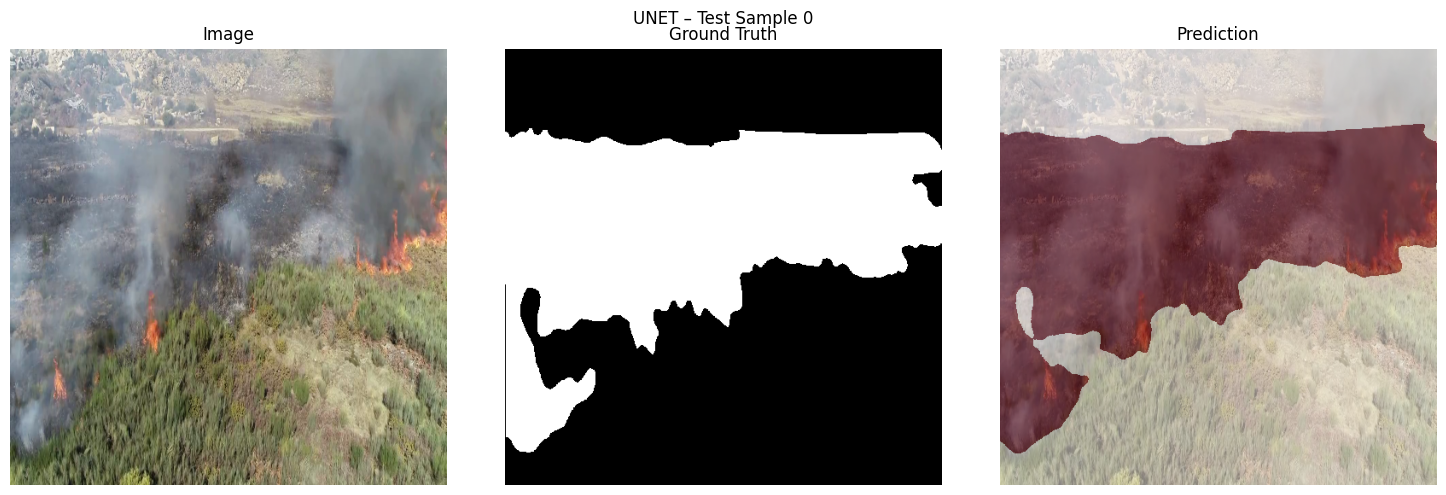

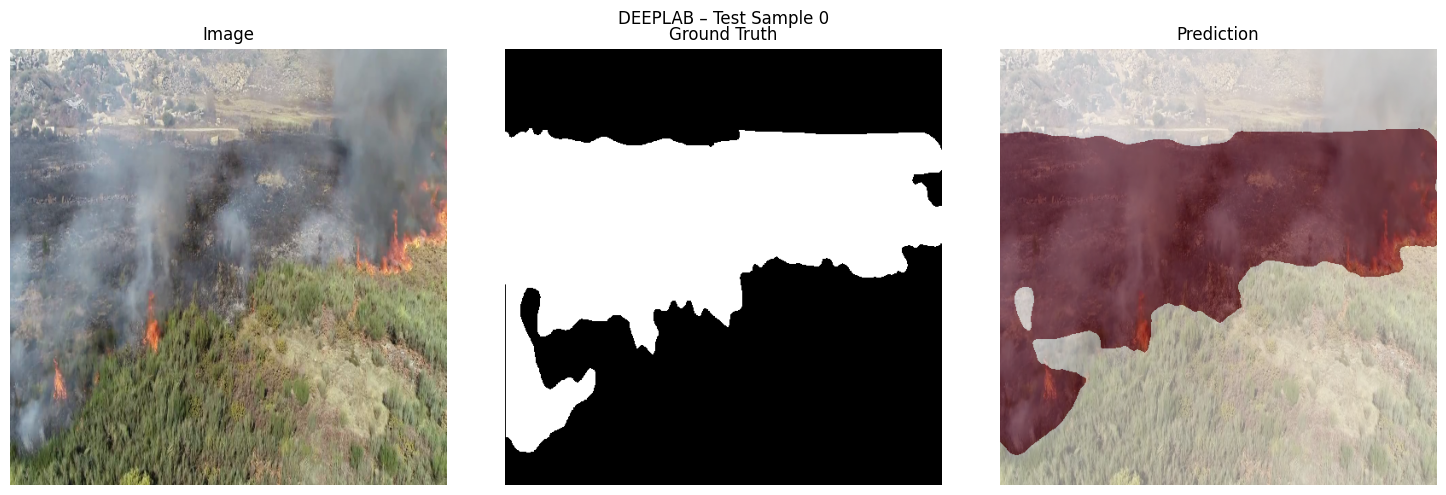

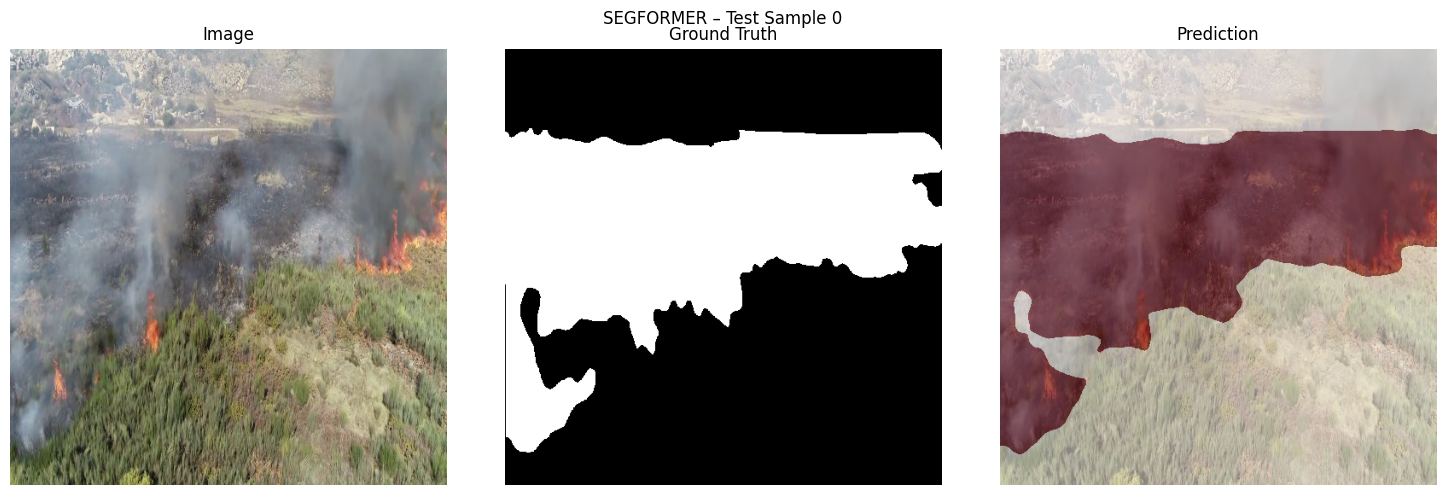

In [17]:
idx = 0  # choose any test image
img, gt_mask = test_ds[idx]

# Convert to numpy for display
img_np = img.permute(1, 2, 0).numpy()
gt_np = gt_mask.squeeze().numpy()

for name, model in models.items():
    pred = predict_mask(model, img.unsqueeze(0), device)

    visualize_prediction(
        image=img_np,
        gt_mask=gt_np,
        pred_mask=pred,
        title=f"{name.upper()} – Test Sample {idx}"
    )